In [1]:
import sys
sys.path.append("..")  # so Python can find the "core" package one level up

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from core.data.preprocess import MovieDataPreprocessor, STUDENT_ID

pipeline = (
    MovieDataPreprocessor()
    .load_raw_data()
    .build_movies_full()
    .build_text_corpus()
    .build_user_item_matrix()
)

# Expose familiar variable names so the analysis cells below
# (sparsity, rating distribution, missing values) keep working unchanged.
ratings = pipeline._ratings
movies = pipeline._movies
links = pipeline._links
movies_full = pipeline.movies_full
text_corpus = pipeline.text_corpus
user_item_matrix = pipeline.user_item_matrix

print(user_item_matrix.shape, text_corpus.shape)

(610, 9724) (3537, 4)


In [2]:
# How many unique users / movies actually appear in the ratings data?
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique() 
n_ratings = len(ratings)

# Sparsity = % of the user-item matrix that has NO rating.
# High sparsity (~98%+) is normal for recommender datasets, but it's
# exactly why plain CF struggles for new users/movies (cold-start).
sparsity = 1- (n_ratings / (n_users * n_movies))

print(f"Unique users: {n_users}")
print(f"Unique movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Matrix Sparsity: {sparsity:.4%}")



Unique users: 610
Unique movies rated: 9724
Total ratings: 100836
Matrix Sparsity: 98.3000%


Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


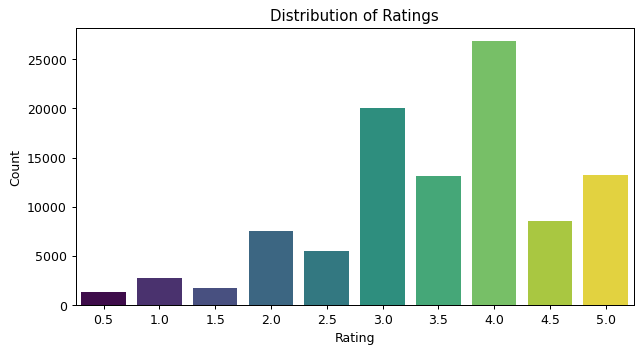

In [3]:
# How are ratings spread out? (0.5 to 5.0 in 0.5 steps)
# This matters because a skewed distribution (e.g. mostly 3-5 stars)
# affects how we interpret RMSE/MAE later in evaluation.

plt.figure(figsize=(8, 4))

# hue=x + legend=False avoids the seaborn deprecation warning
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Check for missing values in movies/links —
# some movies may have no tmdbId, which means no plot overview later.
print("Missing values in movies:\n", movies.isnull().sum())
print("\nMissing values in links:\n", links.isnull().sum())


## Step B.4 — Train / Validation / Test Split (60% / 20% / 20%)

Matches the train/validation/test methodology used in COMP813 Assignment 1
(linear regression) and Assignment 2 (CNN classification): every
hyperparameter is tuned on a **validation** set, and the **test** set is
touched only once, at the very end, to report final numbers. The earlier
80/20 train/test split let SVD's `n_factors` get chosen by looking
directly at test performance — a leak this 3-way split removes.


In [4]:
# 3-way per-user split (60% train / 20% validation / 20% test), seeded with
# the student ID — same convention as Assignment 1's np.random.seed(STUDENT_ID).
ds = pipeline.split()  # defaults: val_frac=0.2, test_frac=0.2, seed=STUDENT_ID

print("Train matrix shape:    ", ds.train_matrix.shape)
print("Trainval matrix shape: ", ds.trainval_matrix.shape, "(train+val, for the final refit)")
print("Train rows:", len(ds.train_df), " Val rows:", len(ds.val_df), " Test rows:", len(ds.test_df))

# Sanity checks:
assert ds.train_matrix.shape == pipeline.user_item_matrix.shape, "Grid mismatch!"
assert len(ds.train_df) + len(ds.val_df) + len(ds.test_df) == len(pipeline.ratings), "Rows lost!"

train_pairs = set(zip(ds.train_df.userId, ds.train_df.movieId))
val_pairs = set(zip(ds.val_df.userId, ds.val_df.movieId))
test_pairs = set(zip(ds.test_df.userId, ds.test_df.movieId))
assert not (train_pairs & val_pairs), "train/val overlap!"
assert not (train_pairs & test_pairs), "train/test overlap!"
assert not (val_pairs & test_pairs), "val/test overlap!"

min_train = ds.train_df.groupby("userId").size().min()
print("Min train ratings per user:", min_train, "(must be >= 1)")
print("\nAll sanity checks passed \u2014 splits are disjoint, exhaustive, every user has train data.")


Train matrix shape:     (610, 9724)
Trainval matrix shape:  (610, 9724) (train+val, for the final refit)
Train rows: 60956  Val rows: 19940  Test rows: 19940
Min train ratings per user: 12 (must be >= 1)

All sanity checks passed — splits are disjoint, exhaustive, every user has train data.


## Step B.5 — Hyperparameter Search: k × damping (selected on VALIDATION)

Mirrors Assignment 1's Task 1 grid search (learning rate × iterations,
selected by a validation-MSE heatmap): here the two SVD hyperparameters
are `n_factors` (k) and `damping` (how strongly an item's bias is shrunk
toward 0 when it has few ratings — `bias = residual_sum / (count + damping)`).
Both are fit on the 60% TRAIN matrix and scored on the 20% VALIDATION set;
TEST is not touched anywhere in this cell.


Validation-selected hyperparameters: k=10, damping=5  (val RMSE=0.8789)


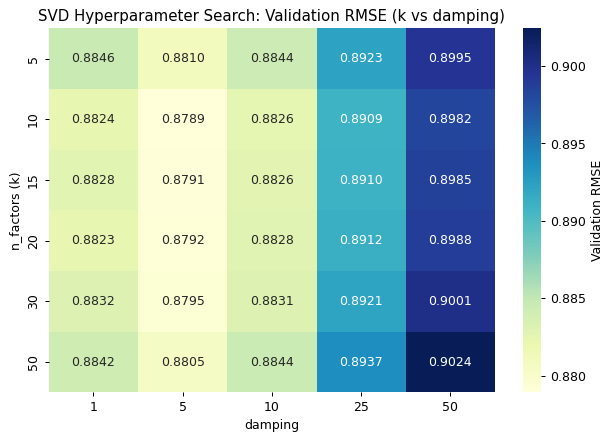

In [5]:
from core.models.svd import SVDRecommender
from core.evaluation.metrics import evaluate, evaluate_model

# 1. Hyperparameter grid to explore
ks = [5, 10, 15, 20, 30, 50]
damps = [1, 5, 10, 25, 50]

val_rmse_matrix = np.zeros((len(ks), len(damps)))
best_rmse, best_k, best_damp, best_model = float("inf"), None, None, None

# 2. Grid search: fit on TRAIN, select on VALIDATION \u2014 same pattern as
#    Assignment 1's "train on TRAIN, select on VALIDATION" loop.
for i, k in enumerate(ks):
    for j, d in enumerate(damps):
        model = SVDRecommender(n_factors=k, damping=d).fit(ds.train_matrix)
        metrics, n_valid, n_total = evaluate_model(model, ds.val_df)
        val_rmse_matrix[i, j] = metrics["RMSE"]

        if metrics["RMSE"] < best_rmse:   # keep the best FITTED MODEL, not just the (k, damp) pair
            best_rmse, best_k, best_damp, best_model = metrics["RMSE"], k, d, model

# 3. Heatmap of validation RMSE
plt.figure(figsize=(7, 5))
sns.heatmap(val_rmse_matrix, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=damps, yticklabels=ks,
            cbar_kws={"label": "Validation RMSE"})
plt.title("SVD Hyperparameter Search: Validation RMSE (k vs damping)")
plt.xlabel("damping"); plt.ylabel("n_factors (k)")
plt.tight_layout(); plt.show()

print(f"Validation-selected hyperparameters: k={best_k}, damping={best_damp}  (val RMSE={best_rmse:.4f})")


## Step B.6 — Final Evaluation (Validation + Test, touched ONCE)

Two results, matching Assignment 1's pattern:
1. The **same fitted model** selected above (trained on the 60% TRAIN
   split) evaluated on both VALIDATION and TEST — directly comparable to
   Assignment 1's `val_best` / `test_best` table.
2. A **deployment model**, refit on TRAIN+VALIDATION (80%) with the same
   validated hyperparameters, evaluated on TEST — the model that would
   actually ship, since discarding the validation 20% at deployment time
   wastes data for no reason.

TEST is evaluated exactly once in the cell below, for every model in the
final comparison table — never again after this.


In [6]:
# --- 1. Assignment-1-style: the SAME model, evaluated on val AND test ---
val_metrics, _, _ = evaluate_model(best_model, ds.val_df)
test_metrics, _, _ = evaluate_model(best_model, ds.test_df)

a1_style_table = pd.DataFrame([
    {"Set": "Validation", **val_metrics},
    {"Set": "Test (touched once, here)", **test_metrics},
])
print("--- Model selected by validation, evaluated on val + test ---")
print(a1_style_table.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))

# --- 2. Deployment model: refit on TRAIN+VAL (80%), same (k, damping) ---
deploy_model = SVDRecommender(n_factors=best_k, damping=best_damp).fit(ds.trainval_matrix)
deploy_metrics, n_valid, n_total = evaluate_model(deploy_model, ds.test_df)
print(f"\n--- Deployment model (refit on train+val, 80%) ---")
print(f"Test RMSE: {deploy_metrics['RMSE']:.4f}  MAE: {deploy_metrics['MAE']:.4f}  (predictions: {n_valid}/{n_total})")

# --- 3. Baseline: user-mean, from the SAME 80% data the deployment model saw ---
user_means = ds.trainval_matrix.mean(axis=1)
baseline_pred = ds.test_df["userId"].map(user_means)
baseline_metrics = evaluate(ds.test_df["rating"], baseline_pred)
print(f"\n--- User-mean baseline (test) ---")
print(f"RMSE: {baseline_metrics['RMSE']:.4f}  MAE: {baseline_metrics['MAE']:.4f}")

# --- 4. External library check: does our custom SVD (with item-bias) beat
#    an off-the-shelf implementation with no item-bias term? Mirrors
#    Assignment 1's "compare against sklearn LinearRegression" step. ---
from sklearn.decomposition import TruncatedSVD

mat = ds.trainval_matrix
means = mat.mean(axis=1)
filled = mat.sub(means, axis=0).fillna(0.0).to_numpy()

sk_svd = TruncatedSVD(n_components=best_k, random_state=STUDENT_ID)
u = sk_svd.fit_transform(filled)
recon = np.clip(u @ sk_svd.components_ + means.to_numpy().reshape(-1, 1), 0.5, 5.0)
recon_df = pd.DataFrame(recon, index=mat.index, columns=mat.columns)

sk_pred = ds.test_df.apply(
    lambda r: recon_df.loc[r["userId"], r["movieId"]] if r["movieId"] in recon_df.columns else np.nan,
    axis=1,
)
sk_valid = sk_pred.notna()
sk_metrics = evaluate(ds.test_df.loc[sk_valid, "rating"], sk_pred[sk_valid])
print(f"\n--- sklearn TruncatedSVD baseline (no item-bias, k={best_k}) ---")
print(f"RMSE: {sk_metrics['RMSE']:.4f}  MAE: {sk_metrics['MAE']:.4f}")

# --- Summary ---
summary = pd.DataFrame([
    {"Model": "User-mean baseline", **baseline_metrics},
    {"Model": f"sklearn TruncatedSVD (k={best_k})", **sk_metrics},
    {"Model": f"Custom SVD, val-selected (k={best_k}, damp={best_damp}) \u2014 train only", **test_metrics},
    {"Model": f"Custom SVD, deployment (k={best_k}, damp={best_damp}) \u2014 train+val", **deploy_metrics},
])
print("\n=== Final test-set comparison (test touched once, in this cell, for every model above) ===")
print(summary.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))


--- Model selected by validation, evaluated on val + test ---
                      Set    MSE   RMSE    MAE
               Validation 0.7725 0.8789 0.6727
Test (touched once, here) 0.7781 0.8821 0.6745

--- Deployment model (refit on train+val, 80%) ---
Test RMSE: 0.8734  MAE: 0.6663  (predictions: 19940/19940)

--- User-mean baseline (test) ---
RMSE: 0.9448  MAE: 0.7353

--- sklearn TruncatedSVD baseline (no item-bias, k=10) ---
RMSE: 0.9153  MAE: 0.7063

=== Final test-set comparison (test touched once, in this cell, for every model above) ===
                                               Model    MSE   RMSE    MAE
                                  User-mean baseline 0.8927 0.9448 0.7353
                         sklearn TruncatedSVD (k=10) 0.8378 0.9153 0.7063
Custom SVD, val-selected (k=10, damp=5) — train only 0.7781 0.8821 0.6745
   Custom SVD, deployment (k=10, damp=5) — train+val 0.7628 0.8734 0.6663
